In [ ]:
# ===== CELL 1: Installs =====
!apt-get -qq update > /dev/null 2>&1
!echo "ttf-mscorefonts-installer msttcorefonts/accepted-mscorefonts-eula select true" | debconf-set-selections
!apt-get -qq install -y ttf-mscorefonts-installer > /dev/null 2>&1
!fc-cache -f > /dev/null 2>&1

# Pin scikit-learn + scikeras to a compatible pair (scikeras breaks on sklearn >= 1.6
# due to the __sklearn_tags__ API rewrite)
!pip install -q --upgrade "scikit-learn==1.5.2" "scikeras==0.13.0" > /dev/null 2>&1

import sklearn, scikeras
print("scikit-learn version:", sklearn.__version__)
print("scikeras version:", scikeras.__version__)
print("Installs complete.")

scikit-learn version: 1.5.2
scikeras version: 0.13.0
Installs complete.


In [ ]:
# ===== CELL 2: Imports, font config, plot/save configuration =====
import os, time, shutil
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import SGD, Adam, RMSprop
from tensorflow.keras.utils import to_categorical
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13

PLOT_DIR = "/content/plots"
os.makedirs(PLOT_DIR, exist_ok=True)

def save_plot(fig, name):
    path = os.path.join(PLOT_DIR, f"{name}.eps")
    fig.savefig(path, format='eps', dpi=600, bbox_inches='tight')
    print(f"Saved: {path}")

CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("Setup complete. TensorFlow version:", tf.__version__)

Setup complete. TensorFlow version: 2.20.0


In [ ]:
# ===== CELL 3: Task 1 - Load dataset =====
(X_train_raw, y_train), (X_test_raw, y_test) = tf.keras.datasets.fashion_mnist.load_data()

print("X_train shape:", X_train_raw.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test_raw.shape)
print("y_test shape :", y_test.shape)
print("Pixel value range:", X_train_raw.min(), "-", X_train_raw.max())

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape : (10000, 28, 28)
y_test shape : (10000,)
Pixel value range: 0 - 255


Saved: /content/plots/sample_images.eps


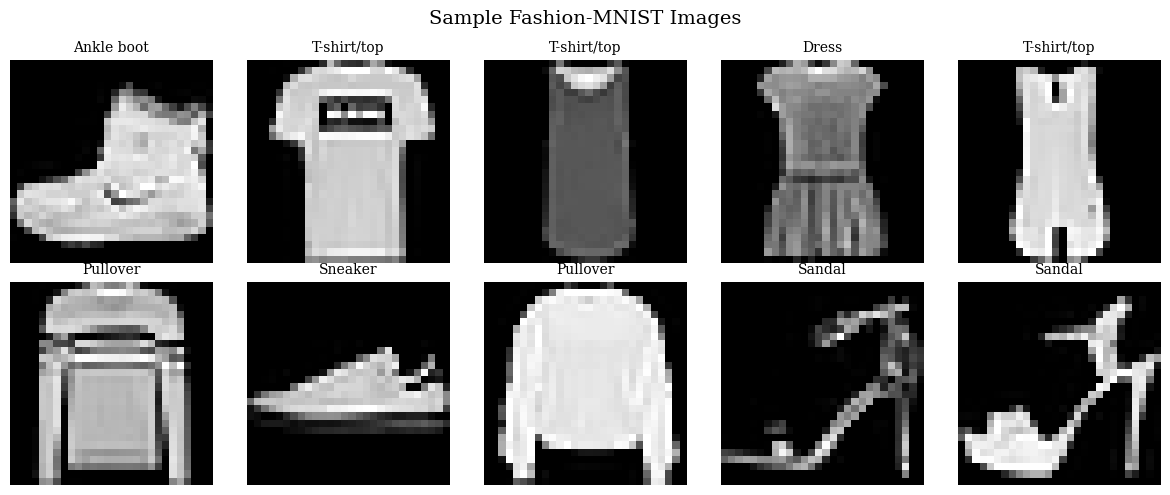

Saved: /content/plots/class_distribution.eps


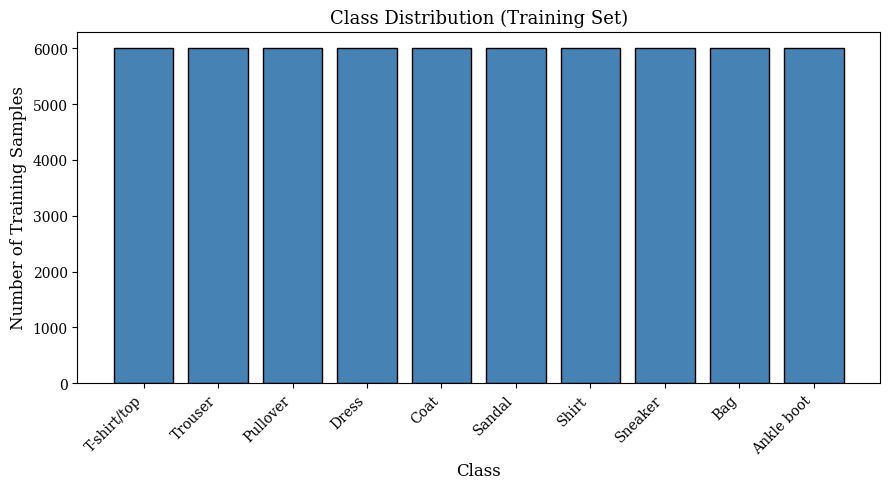

Class counts:
 T-shirt/top    6000
Trouser        6000
Pullover       6000
Dress          6000
Coat           6000
Sandal         6000
Shirt          6000
Sneaker        6000
Bag            6000
Ankle boot     6000
dtype: int64


In [ ]:
# ===== CELL 4: Task 1 - Sample images and class distribution =====
# --- Sample Images ---
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(X_train_raw[i], cmap='gray')
    ax.set_title(CLASS_NAMES[y_train[i]], fontsize=10)
    ax.axis('off')
fig.suptitle('Sample Fashion-MNIST Images', fontsize=14)
plt.tight_layout()
save_plot(fig, "sample_images")
plt.show()

# --- Class Distribution ---
unique, counts = np.unique(y_train, return_counts=True)
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar([CLASS_NAMES[i] for i in unique], counts, color='steelblue', edgecolor='black')
ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Number of Training Samples', fontsize=12)
ax.set_title('Class Distribution (Training Set)', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
save_plot(fig, "class_distribution")
plt.show()

print("Class counts:\n", pd.Series(counts, index=[CLASS_NAMES[i] for i in unique]))

In [ ]:
# ===== CELL 5: Task 2 - Data Preprocessing =====
print("Before preprocessing:")
print("  X_train:", X_train_raw.shape, "| dtype:", X_train_raw.dtype)
print("  X_test :", X_test_raw.shape, "| dtype:", X_test_raw.dtype)

# Flatten
X_train_flat = X_train_raw.reshape(X_train_raw.shape[0], -1)
X_test_flat = X_test_raw.reshape(X_test_raw.shape[0], -1)

# Normalize to [0, 1]
X_train_norm = X_train_flat.astype('float32') / 255.0
X_test_norm = X_test_flat.astype('float32') / 255.0

# One-hot encode labels (for the baseline model, per manual Task 2 spec)
y_train_onehot = to_categorical(y_train, num_classes=10)
y_test_onehot = to_categorical(y_test, num_classes=10)

# Keep integer labels too (needed for sklearn's stratified CV in hyperparameter search)
y_train_int = y_train.copy()
y_test_int = y_test.copy()

print("\nAfter preprocessing:")
print("  X_train_norm  :", X_train_norm.shape, "| dtype:", X_train_norm.dtype)
print("  X_test_norm   :", X_test_norm.shape)
print("  y_train_onehot:", y_train_onehot.shape)
print("  y_test_onehot :", y_test_onehot.shape)
print("  Pixel range after normalization:", X_train_norm.min(), "-", X_train_norm.max())

Before preprocessing:
  X_train: (60000, 28, 28) | dtype: uint8
  X_test : (10000, 28, 28) | dtype: uint8

After preprocessing:
  X_train_norm  : (60000, 784) | dtype: float32
  X_test_norm   : (10000, 784)
  y_train_onehot: (60000, 10)
  y_test_onehot : (10000, 10)
  Pixel range after normalization: 0.0 - 1.0


In [ ]:
# ===== CELL 6: Task 3 - Model Construction =====
baseline_model = Sequential([
    Input(shape=(784,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

baseline_model.compile(optimizer='adam',
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ===== CELL 7: Task 4 - Model Training =====
start_time = time.time()

history = baseline_model.fit(
    X_train_norm, y_train_onehot,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    verbose=1
)

baseline_training_time = time.time() - start_time
print(f"\nBaseline training time: {baseline_training_time:.2f} seconds")

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.8199 - loss: 0.4992 - val_accuracy: 0.8530 - val_loss: 0.4108
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8636 - loss: 0.3741 - val_accuracy: 0.8678 - val_loss: 0.3669
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8750 - loss: 0.3369 - val_accuracy: 0.8690 - val_loss: 0.3624
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8859 - loss: 0.3129 - val_accuracy: 0.8753 - val_loss: 0.3456
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8915 - loss: 0.2938 - val_accuracy: 0.8770 - val_loss: 0.3447
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8946 - loss: 0.2802 - val_accuracy: 0.8812 - val_loss: 0.3330
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9005 - loss: 0.2665 - val_accuracy: 0.8873 - val_loss: 0.3319
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9036 - loss: 0.2576 -

Saved: /content/plots/training_accuracy_vs_epoch.eps


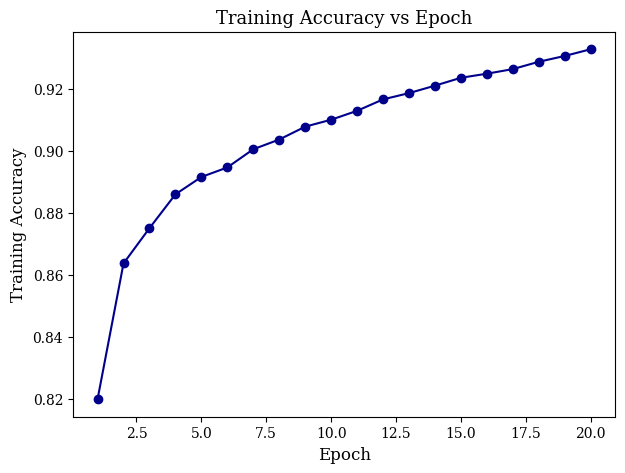

Saved: /content/plots/validation_accuracy_vs_epoch.eps


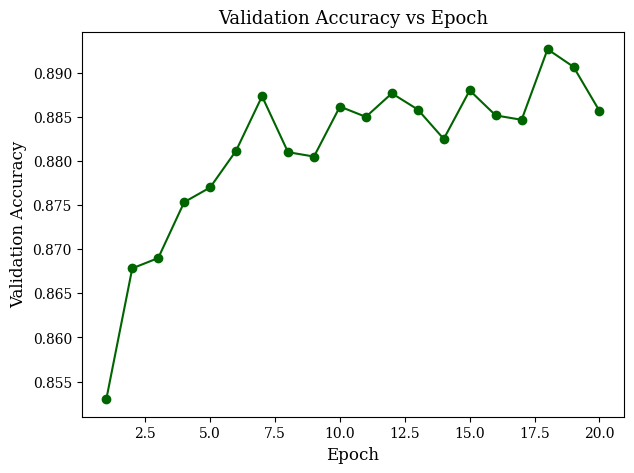

Saved: /content/plots/training_loss_vs_epoch.eps


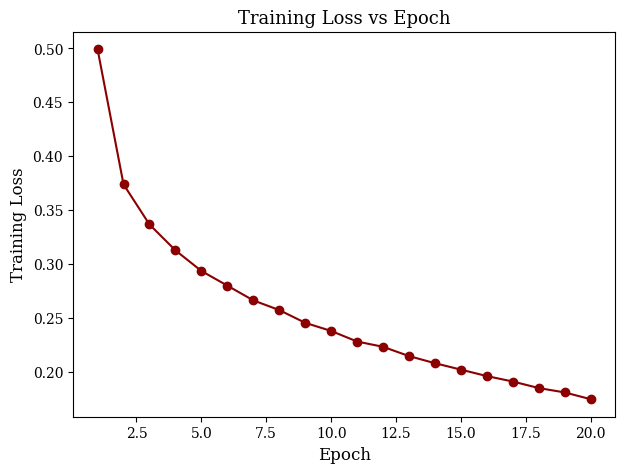

Saved: /content/plots/validation_loss_vs_epoch.eps


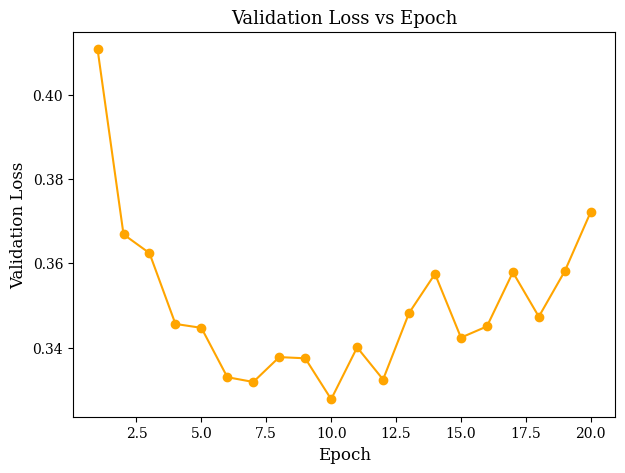

In [ ]:
# ===== CELL 8: Plots - Accuracy and Loss curves =====
epochs_range = range(1, len(history.history['accuracy']) + 1)

# --- Training Accuracy vs Epoch ---
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(epochs_range, history.history['accuracy'], marker='o', color='darkblue')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Training Accuracy', fontsize=12)
ax.set_title('Training Accuracy vs Epoch', fontsize=13)
save_plot(fig, "training_accuracy_vs_epoch")
plt.show()

# --- Validation Accuracy vs Epoch ---
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(epochs_range, history.history['val_accuracy'], marker='o', color='darkgreen')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Validation Accuracy', fontsize=12)
ax.set_title('Validation Accuracy vs Epoch', fontsize=13)
save_plot(fig, "validation_accuracy_vs_epoch")
plt.show()

# --- Training Loss vs Epoch ---
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(epochs_range, history.history['loss'], marker='o', color='darkred')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Training Loss', fontsize=12)
ax.set_title('Training Loss vs Epoch', fontsize=13)
save_plot(fig, "training_loss_vs_epoch")
plt.show()

# --- Validation Loss vs Epoch ---
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(epochs_range, history.history['val_loss'], marker='o', color='orange')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Validation Loss', fontsize=12)
ax.set_title('Validation Loss vs Epoch', fontsize=13)
save_plot(fig, "validation_loss_vs_epoch")
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Baseline Accuracy : 0.8838
Baseline Precision: 0.8877
Baseline Recall   : 0.8838
Baseline F1-score : 0.8847

Classification Report:
               precision    recall  f1-score   support

 T-shirt/top       0.87      0.77      0.81      1000
     Trouser       0.98      0.98      0.98      1000
    Pullover       0.82      0.78      0.80      1000
       Dress       0.92      0.85      0.88      1000
        Coat       0.78      0.83      0.81      1000
      Sandal       0.97      0.97      0.97      1000
       Shirt       0.67      0.78      0.72      1000
     Sneaker       0.96      0.94      0.95      1000
         Bag       0.97      0.97      0.97      1000
  Ankle boot       0.94      0.97      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.89      0.88      0.88     10000
weighted avg       0.89      0.88      0.88     10000

Saved: /content/plots/confusion_matrix.eps


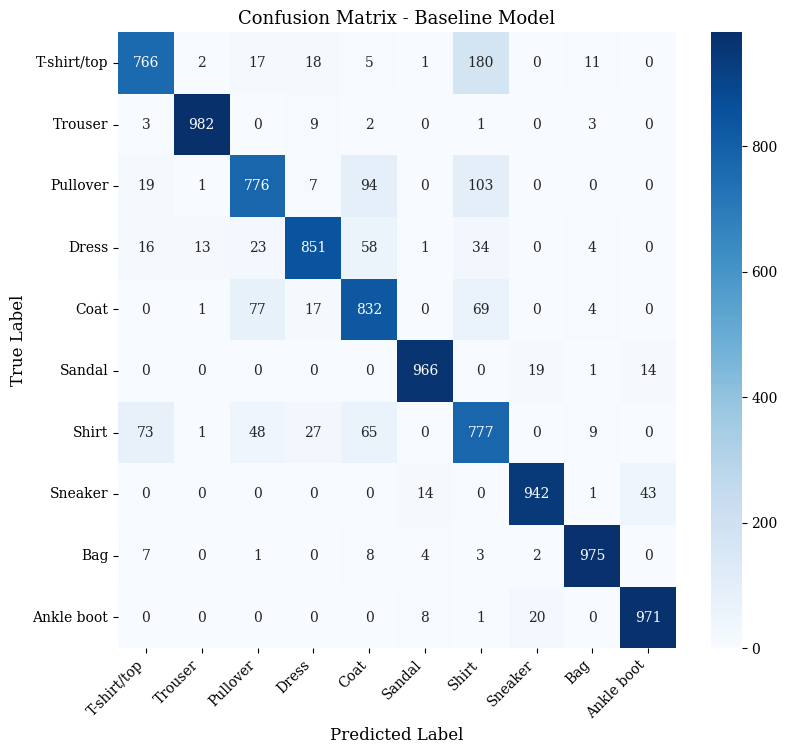

In [ ]:
# ===== CELL 9: Task 5 - Baseline Model Evaluation =====
y_pred_probs = baseline_model.predict(X_test_norm)
y_pred = np.argmax(y_pred_probs, axis=1)

baseline_acc = accuracy_score(y_test_int, y_pred)
baseline_prec = precision_score(y_test_int, y_pred, average='macro')
baseline_rec = recall_score(y_test_int, y_pred, average='macro')
baseline_f1 = f1_score(y_test_int, y_pred, average='macro')
cm = confusion_matrix(y_test_int, y_pred)

print(f"Baseline Accuracy : {baseline_acc:.4f}")
print(f"Baseline Precision: {baseline_prec:.4f}")
print(f"Baseline Recall   : {baseline_rec:.4f}")
print(f"Baseline F1-score : {baseline_f1:.4f}")
print("\nClassification Report:\n", classification_report(y_test_int, y_pred, target_names=CLASS_NAMES))

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix - Baseline Model', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
save_plot(fig, "confusion_matrix")
plt.show()

In [ ]:
# ===== CELL 10: Hyperparameter Optimization - manual RandomizedSearchCV equivalent =====
# Avoids the scikeras/scikit-learn __sklearn_tags__ incompatibility entirely by
# implementing the random search + 5-fold CV loop directly with Keras + StratifiedKFold.
import random
from sklearn.model_selection import StratifiedKFold

random.seed(43)
np.random.seed(43)

param_distributions = {
    'hidden_layers': [1, 2, 3],
    'hidden_neurons': [32, 64, 128, 256],
    'learning_rate': [0.1, 0.01, 0.001],
    'batch_size': [16, 32, 64, 128],
    'epochs': [10, 20, 30],
    'optimizer': ['sgd', 'adam', 'rmsprop'],
    'activation': ['relu', 'tanh', 'sigmoid'],
    'dropout': [0.0, 0.2, 0.5]
}

def sample_params():
    return {k: random.choice(v) for k, v in param_distributions.items()}

def build_search_model(hidden_layers, hidden_neurons, learning_rate,
                        optimizer, activation, dropout):
    model = Sequential()
    model.add(Input(shape=(784,)))
    for _ in range(hidden_layers):
        model.add(Dense(hidden_neurons, activation=activation))
        if dropout > 0:
            model.add(Dropout(dropout))
    model.add(Dense(10, activation='softmax'))

    if optimizer == 'sgd':
        opt = SGD(learning_rate=learning_rate)
    elif optimizer == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate)
    else:
        opt = Adam(learning_rate=learning_rate)

    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Stratified subsample for the search (10% of training data) - same as before
X_search, _, y_search, _ = train_test_split(
    X_train_norm, y_train_int, train_size=0.10, random_state=42, stratify=y_train_int
)
print("Search subsample size:", X_search.shape)

N_ITER = 20
CV_FOLDS = 5
skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)

search_results = []

for i in range(N_ITER):
    params = sample_params()
    fold_scores = []
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_search, y_search)):
        model = build_search_model(
            hidden_layers=params['hidden_layers'],
            hidden_neurons=params['hidden_neurons'],
            learning_rate=params['learning_rate'],
            optimizer=params['optimizer'],
            activation=params['activation'],
            dropout=params['dropout']
        )
        model.fit(X_search[train_idx], y_search[train_idx],
                  epochs=params['epochs'], batch_size=params['batch_size'], verbose=0)
        _, val_acc = model.evaluate(X_search[val_idx], y_search[val_idx], verbose=0)
        fold_scores.append(val_acc)

    mean_score = np.mean(fold_scores)
    std_score = np.std(fold_scores)
    search_results.append({**params, 'mean_test_score': mean_score, 'std_test_score': std_score})
    print(f"Candidate {i+1}/{N_ITER} | mean CV acc: {mean_score:.4f} | params: {params}")

results_df = pd.DataFrame(search_results)
best_row = results_df.loc[results_df['mean_test_score'].idxmax()]
best_params = {k: best_row[k] for k in param_distributions.keys()}
best_score = best_row['mean_test_score']

print("\nBest hyperparameters found:")
for k, v in best_params.items():
    print(f"  {k}: {v}")
print(f"\nBest cross-validation accuracy: {best_score:.4f}")

Search subsample size: (6000, 784)
Candidate 1/20 | mean CV acc: 0.8357 | params: {'hidden_layers': 1, 'hidden_neurons': 128, 'learning_rate': 0.001, 'batch_size': 32, 'epochs': 20, 'optimizer': 'adam', 'activation': 'sigmoid', 'dropout': 0.5}
Candidate 2/20 | mean CV acc: 0.8233 | params: {'hidden_layers': 2, 'hidden_neurons': 256, 'learning_rate': 0.1, 'batch_size': 16, 'epochs': 10, 'optimizer': 'sgd', 'activation': 'tanh', 'dropout': 0.0}
Candidate 3/20 | mean CV acc: 0.3397 | params: {'hidden_layers': 1, 'hidden_neurons': 32, 'learning_rate': 0.1, 'batch_size': 16, 'epochs': 10, 'optimizer': 'adam', 'activation': 'tanh', 'dropout': 0.0}
Candidate 4/20 | mean CV acc: 0.8328 | params: {'hidden_layers': 1, 'hidden_neurons': 256, 'learning_rate': 0.001, 'batch_size': 64, 'epochs': 20, 'optimizer': 'rmsprop', 'activation': 'sigmoid', 'dropout': 0.5}
Candidate 5/20 | mean CV acc: 0.7862 | params: {'hidden_layers': 3, 'hidden_neurons': 32, 'learning_rate': 0.001, 'batch_size': 16, 'epoch

In [ ]:
best_params = {
    'hidden_layers': int(best_row['hidden_layers']),
    'hidden_neurons': int(best_row['hidden_neurons']),
    'learning_rate': float(best_row['learning_rate']),
    'batch_size': int(best_row['batch_size']),
    'epochs': int(best_row['epochs']),
    'optimizer': str(best_row['optimizer']),
    'activation': str(best_row['activation']),
    'dropout': float(best_row['dropout'])
}

In [ ]:
# ===== CELL 11: Retrain optimized model (Task 5) =====
# best_params already exists from Cell 10 - no need to pull it from a "search" object
# (delete this line if it's still here: best_params = search.best_params_)

optimized_model = build_search_model(
    hidden_layers=best_params['hidden_layers'],
    hidden_neurons=best_params['hidden_neurons'],
    learning_rate=best_params['learning_rate'],
    optimizer=best_params['optimizer'],
    activation=best_params['activation'],
    dropout=best_params['dropout']
)

start_time = time.time()
opt_history = optimized_model.fit(
    X_train_norm, y_train_int,
    validation_split=0.1,
    epochs=best_params['epochs'],
    batch_size=best_params['batch_size'],
    verbose=1
)
optimized_training_time = time.time() - start_time
print(f"\nOptimized model training time: {optimized_training_time:.2f} seconds")

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8139 - loss: 0.5375 - val_accuracy: 0.8470 - val_loss: 0.4288
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8586 - loss: 0.3978 - val_accuracy: 0.8570 - val_loss: 0.3894
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8713 - loss: 0.3618 - val_accuracy: 0.8713 - val_loss: 0.3577
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8807 - loss: 0.3285 - val_accuracy: 0.8753 - val_loss: 0.3512
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8879 - loss: 0.3075 - val_accuracy: 0.8810 - val_loss: 0.3295
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8927 - loss: 0.2912 - val_accuracy: 0.8753 - val_loss: 0.3457
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8983 - loss: 0.2782 - val_accuracy: 0.8820 - val_loss: 0.3165
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9020 - loss: 0.2667 - val_accuracy: 0.

In [ ]:
# ===== CELL 12: Evaluate optimized model (Task 6) =====
y_pred_opt_probs = optimized_model.predict(X_test_norm)
y_pred_opt = np.argmax(y_pred_opt_probs, axis=1)

optimized_acc = accuracy_score(y_test_int, y_pred_opt)
optimized_prec = precision_score(y_test_int, y_pred_opt, average='macro')
optimized_rec = recall_score(y_test_int, y_pred_opt, average='macro')
optimized_f1 = f1_score(y_test_int, y_pred_opt, average='macro')

print(f"Optimized Accuracy : {optimized_acc:.4f}")
print(f"Optimized Precision: {optimized_prec:.4f}")
print(f"Optimized Recall   : {optimized_rec:.4f}")
print(f"Optimized F1-score : {optimized_f1:.4f}")
print("\nClassification Report (Optimized):\n",
      classification_report(y_test_int, y_pred_opt, target_names=CLASS_NAMES))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Optimized Accuracy : 0.8908
Optimized Precision: 0.8909
Optimized Recall   : 0.8908
Optimized F1-score : 0.8906

Classification Report (Optimized):
               precision    recall  f1-score   support

 T-shirt/top       0.84      0.83      0.84      1000
     Trouser       0.99      0.98      0.98      1000
    Pullover       0.80      0.81      0.80      1000
       Dress       0.85      0.93      0.89      1000
        Coat       0.83      0.79      0.81      1000
      Sandal       0.97      0.97      0.97      1000
       Shirt       0.72      0.71      0.72      1000
     Sneaker       0.95      0.97      0.96      1000
         Bag       0.98      0.96      0.97      1000
  Ankle boot       0.97      0.95      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



Saved: /content/plots/hyperparameter_search_results.eps


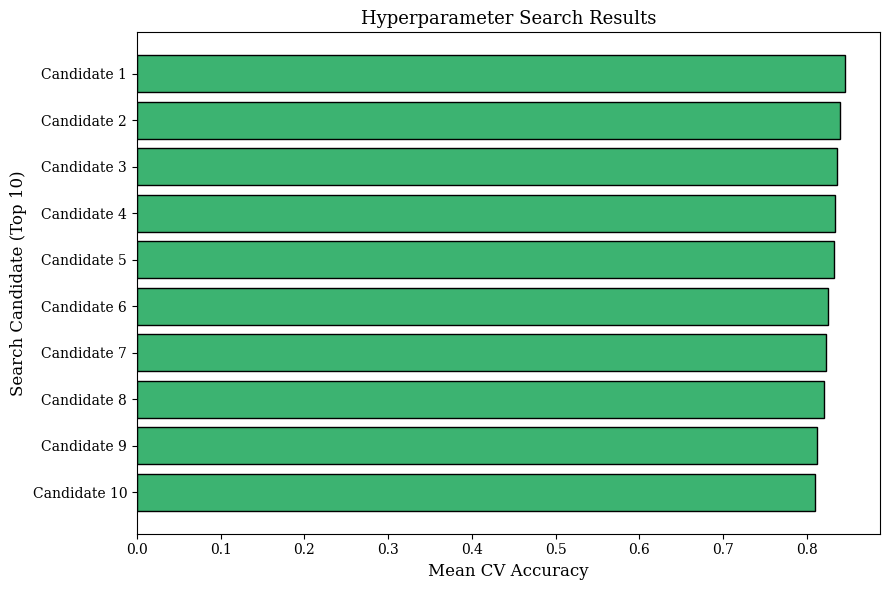

   hidden_layers  hidden_neurons  learning_rate  batch_size  epochs optimizer activation  dropout  mean_test_score  std_test_score
0              1             256          0.001         128      20      adam       relu      0.0         0.845333        0.008718
1              3             256          0.001         128      30   rmsprop       relu      0.0         0.839333        0.017024
2              1             128          0.001          32      20      adam    sigmoid      0.5         0.835667        0.006612
3              2             256          0.100          32      20       sgd       relu      0.2         0.834333        0.017016
4              1             256          0.001          64      20   rmsprop    sigmoid      0.5         0.832833        0.004905
5              3              64          0.010          64      20   rmsprop       relu      0.0         0.825667        0.016803
6              2             256          0.100          16      10       sgd      

In [ ]:
# ===== CELL 13: Plot - Hyperparameter Search Results =====
# results_df already exists from Cell 10 (manual search loop) - no need to rebuild it
top_results = results_df.sort_values('mean_test_score', ascending=False).head(10).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(range(len(top_results)), top_results['mean_test_score'], color='mediumseagreen', edgecolor='black')
ax.set_yticks(range(len(top_results)))
ax.set_yticklabels([f"Candidate {i+1}" for i in range(len(top_results))])
ax.invert_yaxis()
ax.set_xlabel('Mean CV Accuracy', fontsize=12)
ax.set_ylabel('Search Candidate (Top 10)', fontsize=12)
ax.set_title('Hyperparameter Search Results', fontsize=13)
plt.tight_layout()
save_plot(fig, "hyperparameter_search_results")
plt.show()

param_cols = list(param_distributions.keys())
print(top_results[param_cols + ['mean_test_score', 'std_test_score']].to_string())

Saved: /content/plots/best_model_accuracy_comparison.eps


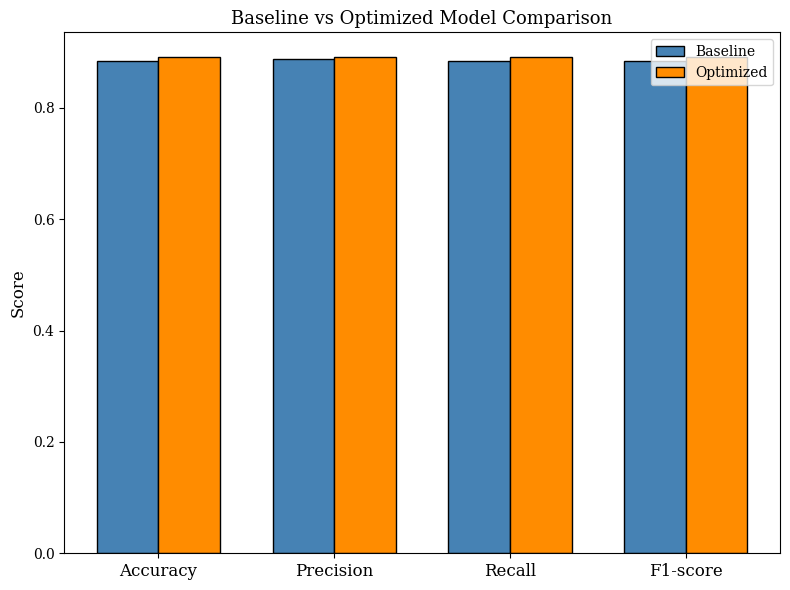

In [ ]:
# ===== CELL 14: Plot - Best Model Accuracy Comparison =====
metrics_labels = ['Accuracy', 'Precision', 'Recall', 'F1-score']
baseline_scores = [baseline_acc, baseline_prec, baseline_rec, baseline_f1]
optimized_scores = [optimized_acc, optimized_prec, optimized_rec, optimized_f1]

x = np.arange(len(metrics_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(x - width/2, baseline_scores, width, label='Baseline', color='steelblue', edgecolor='black')
ax.bar(x + width/2, optimized_scores, width, label='Optimized', color='darkorange', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels, fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Baseline vs Optimized Model Comparison', fontsize=13)
ax.legend()
plt.tight_layout()
save_plot(fig, "best_model_accuracy_comparison")
plt.show()

In [ ]:
# ===== CELL 15: Summary Tables =====
best_hparams_table = pd.DataFrame({
    "Hyperparameter": ["Hidden Layers", "Hidden Neurons", "Learning Rate", "Batch Size",
                        "Optimizer", "Activation Function", "Epochs", "Dropout",
                        "Cross-validation Accuracy", "Testing Accuracy"],
    "Value": [best_params['hidden_layers'], best_params['hidden_neurons'], best_params['learning_rate'],
              best_params['batch_size'], best_params['optimizer'], best_params['activation'],
              best_params['epochs'], best_params['dropout'],
              round(best_score, 4), round(optimized_acc, 4)]
})
print("Best Hyperparameters:\n", best_hparams_table.to_string(index=False))

comparison_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "Training Time (s)"],
    "Baseline": [round(baseline_acc,4), round(baseline_prec,4), round(baseline_rec,4),
                 round(baseline_f1,4), round(baseline_training_time,2)],
    "Optimized": [round(optimized_acc,4), round(optimized_prec,4), round(optimized_rec,4),
                  round(optimized_f1,4), round(optimized_training_time,2)]
})
print("\nPerformance Comparison:\n", comparison_table.to_string(index=False))

Best Hyperparameters:
            Hyperparameter   Value
            Hidden Layers       1
           Hidden Neurons     256
            Learning Rate   0.001
               Batch Size     128
                Optimizer    adam
      Activation Function    relu
                   Epochs      20
                  Dropout     0.0
Cross-validation Accuracy  0.8453
         Testing Accuracy  0.8908

Performance Comparison:
            Metric  Baseline  Optimized
         Accuracy    0.8838     0.8908
        Precision    0.8877     0.8909
           Recall    0.8838     0.8908
         F1-score    0.8847     0.8906
Training Time (s)  115.7300    29.7000


In [ ]:
# ===== CELL 16: Zip and download all plots =====
from google.colab import files

zip_path = "/content/experiment2_plots"
shutil.make_archive(zip_path, 'zip', PLOT_DIR)

print("Files in archive:")
for f in os.listdir(PLOT_DIR):
    print(" -", f)

files.download(zip_path + ".zip")

Files in archive:
 - training_accuracy_vs_epoch.eps
 - validation_accuracy_vs_epoch.eps
 - sample_images.eps
 - validation_loss_vs_epoch.eps
 - training_loss_vs_epoch.eps
 - confusion_matrix.eps
 - best_model_accuracy_comparison.eps
 - hyperparameter_search_results.eps
 - class_distribution.eps


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>